# Get the data!

K8s and Kepler.

In [1]:
import os
import glob
import shutil
import subprocess

from experiment.vm_power_prediction import X_train


def get_data(token: str, start: str, stop: str, output_dir_kepler: str, output_dir_k8s: str):
    """
    Fetch data from InfluxDB for 'kepler' and 'k8s' plugins and save as CSV files.

    Args:
        token (str): InfluxDB access token.
        start (str): Start of time range (e.g., '2025-01-01T00:00:00Z').
        stop (str): End of time range (e.g., '2025-01-02T00:00:00Z').
        output_dir_kepler (str): Directory to save kepler CSVs.
        output_dir_k8s (str): Directory to save k8s CSVs.
    """

    def run_query_and_save(plugin: str, output_dir: str):
        tmp_dir = f"/tmp/{plugin}_raw"
        os.makedirs(tmp_dir, exist_ok=True)

        # Run influx query, saving all CSVs in tmp_dir
        subprocess.run([
            "query-influxdb",
            "--token", token,
            "--range", f"start: {start}, stop: {stop}",
            "--plugin", plugin,
            "--output-dir", tmp_dir
        ], check=True)

        # Copy all CSVs to the final output directory
        os.makedirs(output_dir, exist_ok=True)
        for csv_file in glob.glob(os.path.join(tmp_dir, "*.csv")):
            shutil.copy(csv_file, output_dir)
            print(f"{plugin} CSV copied: {csv_file} -> {output_dir}")

    # Fetch kepler and k8s data
    run_query_and_save("kepler", output_dir_kepler)
    run_query_and_save("k8s", output_dir_k8s)

    print("Data fetching done. CSVs saved in plugin directories.")


In [ ]:
TOKEN = "XXXXXXX"

get_data(TOKEN, "2025-08-23T19:10:50Z", "2025-08-25T19:10:50Z",
         output_dir_kepler="data/kepler",
         output_dir_k8s="data/k8s")

🔄 Running queries for plugin: kepler
🔄 Running query to get inventory IDs: from(bucket: "monitoring")
      |> range(start: 2025-08-23T19:10:50Z, stop: 2025-08-25T19:10:50Z)
      |> filter(fn: (r) =>
        r.vm_name =~ /^neuronet-/ and
        r.plugin == "proxmox")
🔄 Running query: from(bucket: "monitoring")
        |> range(start: 2025-08-23T19:10:50Z, stop: 2025-08-25T19:10:50Z)
        |> filter(fn: (r) => r.plugin == "kepler")
      |> filter(fn: (r) => r["inventory-server-id"] =~ /Neuronet/)


In [77]:
import os
import pandas as pd
import joblib
import glob
from sklearn.preprocessing import StandardScaler

# Import your custom NEURONET modules
from neuronet.datasets.energy_dataset import EnergyDatasetBuilder
from neuronet.preprocessing.kepler import KeplerPreprocessor
from neuronet.preprocessing.k8s import K8SProcessor


def preprocess_data(
    input_kepler_dir: str,
    input_k8s_dir: str,
    features: list[str],
    test_perc: float,
    val_perc: float,
    output_folder: str,
):
    """
    Preprocess Kepler and K8S datasets, combine them, scale features, and save splits.

    Args:
        input_kepler_dir (str): Path to the Kepler dataset directory.
        input_k8s_dir (str): Path to the K8S dataset directory.
        features (list[str]): List of feature column names to keep.
        test_perc (float): Fraction of data to use for testing.
        val_perc (float): Fraction of data to use for validation.
        output_folder (str): Directory to save output files.
    """
    # read csv file in kepler and k8s directories
    kepler_files = glob.glob(os.path.join(input_kepler_dir, "*.csv"))
    k8s_files = glob.glob(os.path.join(input_k8s_dir, "*.csv"))
    kepler_df = pd.concat([pd.read_csv(f) for f in kepler_files], ignore_index=True)
    k8s_df = pd.concat([pd.read_csv(f) for f in k8s_files], ignore_index=True)

    # Step 1: Preprocess Kepler data
    kepler_processor = KeplerPreprocessor(kepler_df)
    os.makedirs(os.path.join(input_kepler_dir, "processed"), exist_ok=True)
    kepler_df_processed = kepler_processor.run(output_csv="kepler_processed.csv")
    kepler_df_processed.to_csv(os.path.join(input_kepler_dir, "processed", "kepler_processed.csv"), index=False)
    print(f"Kepler processed shape: {kepler_df_processed.shape}")

    # Step 2: Preprocess K8S data
    k8s_processor = K8SProcessor(k8s_df)
    os.makedirs(os.path.join(input_k8s_dir, "processed"), exist_ok=True)
    k8s_df_processed = k8s_processor.run(output_csv="k8s_processed.csv")
    k8s_df_processed.to_csv(os.path.join(input_k8s_dir, "processed", "k8s_processed.csv"), index=False)
    print(f"K8S processed shape: {k8s_df.shape}")

    # Step 3: Combine datasets
    builder = EnergyDatasetBuilder(k8s_df_processed, kepler_df_processed, interval="1min")
    energy_dataset = builder.build()
    energy_dataset["_time"] = pd.to_datetime(energy_dataset["_time"])
    energy_dataset = energy_dataset.set_index("_time").sort_index().reset_index()
    print(f"Combined energy dataset shape: {energy_dataset.shape}")

    # Step 4: Select features
    df = energy_dataset[features]

    # Step 5: Timeseries splits
    train_end = int(len(df) * (1 - test_perc - val_perc))
    val_end = int(len(df) * (1 - test_perc))
    train_df = df.iloc[:train_end]
    val_df = df.iloc[train_end:val_end]
    test_df = df.iloc[val_end:]

    # Step 6: Scale features
    scaler = StandardScaler()
    scaler.fit(train_df)

    os.makedirs(output_folder, exist_ok=True)
    joblib.dump(scaler, os.path.join(output_folder, "scaler.joblib"))

    train_scaled = pd.DataFrame(scaler.transform(train_df), columns=train_df.columns, index=train_df.index)
    val_scaled = pd.DataFrame(scaler.transform(val_df), columns=val_df.columns, index=val_df.index)
    test_scaled = pd.DataFrame(scaler.transform(test_df), columns=test_df.columns, index=test_df.index)

    os.makedirs(os.path.dirname(output_folder), exist_ok=True)
    # Save splits
    train_scaled.to_csv(os.path.join(output_folder, "train.csv"), index=False)
    val_scaled.to_csv(os.path.join(output_folder, "val.csv"), index=False)
    test_scaled.to_csv(os.path.join(output_folder, "test.csv"), index=False)
    # print first 5 rows of train_scaled
    print("First 5 rows of scaled training data:")
    print(train_scaled.head())
    print("Preprocessing done. Artifacts saved.")


In [78]:

preprocess_data(
    input_kepler_dir="data/kepler",
    input_k8s_dir="data/k8s",
    features=["cpu_millicores","memory_usage_mb","logsfs_usage_percent", "container_power_watts"],
    test_perc=0.2,
    val_perc=0.1,
    output_folder="data/outputs",
)

KEPLER!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
_field                     _time  \
0      2025-08-23 19:11:00+00:00   
1      2025-08-23 19:11:00+00:00   
2      2025-08-23 19:11:00+00:00   
3      2025-08-23 19:11:00+00:00   
4      2025-08-23 19:11:00+00:00   

_field                                       container_id  \
0       0208ecb6cccf44b5fb4ad972482aacac3dc304d1763294...   
1       045a9e16dae65232f9ca1b132e689caf90de598a646604...   
2       058308c1087f7fcfbfcb758fb4c7942e9f9d5a5f3966dd...   
3       0a0443e983dc66fd021cda7576142ae71038263b43d1ab...   
4       0be5155a227101c05f3b2945baa57faa987d16d42d499a...   

_field         container_name               namespace  \
0               node-exporter              monitoring   
1          install-cni-plugin            kube-flannel   
2              ovs-cni-marker  cluster-network-addons   
3          install-cni-plugin            kube-flannel   
4       install-multus-binary             kube-system   

_field                      

In [79]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import joblib
import torch.nn.functional as F
from iTransformer import iTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


class TimeSeriesDataset(Dataset):
    def __init__(self, df, lookback, horizon):
        self.X = df.values.astype("float32")
        self.lookback, self.horizon = lookback, horizon

    def __len__(self):
        return len(self.X) - self.lookback - self.horizon + 1

    def __getitem__(self, i):
        x = self.X[i: i + self.lookback]       # (lookback, num_features)
        y = self.X[i + self.lookback: i + self.lookback + self.horizon]  # (horizon, num_features)

        # Return as torch tensors
        return torch.from_numpy(x), torch.from_numpy(y)


def train_evaluate_model(
    input_train: str,
    input_val: str,
    input_test: str,
    input_scaler: str,
    lookback: int,
    horizon: int,
    output_model: str,
):
    # Load datasets
    X_train = pd.read_csv(input_train)
    X_val = pd.read_csv(input_val)
    X_test = pd.read_csv(input_test)
    feature_names = X_train.columns.tolist()

    print(X_train.shape, X_val.shape, X_test.shape)

    # Torch datasets + loaders
    train_ds = TimeSeriesDataset(X_train, lookback, horizon)
    val_ds = TimeSeriesDataset(X_val, lookback, horizon)
    test_ds = TimeSeriesDataset(X_test, lookback, horizon)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32)
    test_loader = DataLoader(test_ds, batch_size=32)

    # Model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = iTransformer(
        num_variates=X_train.shape[1],
        lookback_len=lookback,
        dim=128,
        depth=4,
        heads=8,
        dim_head=64,
        pred_length=horizon,   # FIX: int not tuple
        num_tokens_per_variate=1,
        use_reversible_instance_norm=True,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  # safer LR
    num_epochs = 500

    # Early stopping
    patience = 10   # allow more epochs before stopping
    best_val_loss = float("inf")
    patience_counter = 0
    best_model_state = None

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        for x, y_true in train_loader:
            x, y_true = x.to(device), y_true.to(device)

            # Make sure input shape matches model expectation
            # Some implementations expect (batch, num_features, lookback)
            # if model.expect_shape == "channels_first":  # <-- check if attr exists, else just permute manually
            #     x = x.permute(0, 2, 1)  # (batch, features, lookback)

            optimizer.zero_grad()
            y_pred = model(x)

            if isinstance(y_pred, dict):
                y_pred = next(iter(y_pred.values()))

            if y_pred.shape != y_true.shape:
                raise ValueError(f"Shape mismatch: {y_pred.shape} vs {y_true.shape}")

            loss = F.mse_loss(y_pred, y_true)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # Validation
        model.eval()
        val_losses = []
        with torch.no_grad():
            for x, y_true in val_loader:
                x, y_true = x.to(device), y_true.to(device)
                # if model.expect_shape == "channels_first":
                #     x = x.permute(0, 2, 1)
                y_pred = model(x)
                if isinstance(y_pred, dict):
                    y_pred = next(iter(y_pred.values()))
                val_losses.append(F.mse_loss(y_pred, y_true).item())

        avg_train_loss = sum(train_losses) / len(train_losses)
        avg_val_loss = sum(val_losses) / len(val_losses)

        print(
            f"Epoch {epoch + 1}/{num_epochs} "
            f"train_loss: {avg_train_loss:.4f} "
            f"val_loss: {avg_val_loss:.4f}"
        )

        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"⏹️ Early stopping at epoch {epoch + 1}")
                break

    # Save the best model (not the last one)
    torch.save(best_model_state, output_model)
    print(f"✅ Best model saved to {output_model}")

    # Evaluate on test set
    model.load_state_dict(best_model_state)  # ensure best weights
    model.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for x, y_true in test_loader:
            x, y_true = x.to(device), y_true.to(device)
            # if model.expect_shape == "channels_first":
            #     x = x.permute(0, 2, 1)
            y_pred = model(x)
            if isinstance(y_pred, dict):
                y_pred = next(iter(y_pred.values()))
            all_preds.append(y_pred.cpu())
            all_trues.append(y_true.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_trues = torch.cat(all_trues).numpy()

    # Flatten for metrics
    flat_preds = all_preds.reshape(-1, all_preds.shape[-1])
    flat_trues = all_trues.reshape(-1, all_trues.shape[-1])

    # Inverse scale
    scaler = joblib.load(input_scaler)
    flat_preds_original = scaler.inverse_transform(flat_preds)
    flat_trues_original = scaler.inverse_transform(flat_trues)

    # Metrics
    print("\n📊 Per-variable MAE / MSE / R²:")
    for i, col in enumerate(feature_names):
        mae = mean_absolute_error(flat_trues_original[:, i], flat_preds_original[:, i])
        mse = mean_squared_error(flat_trues_original[:, i], flat_preds_original[:, i])
        r2 = r2_score(flat_trues_original[:, i], flat_preds_original[:, i])
        print(f"{col}: MAE = {mae:.4f}, MSE = {mse:.4f}, R2 = {r2:.4f}")

    overall_mae = mean_absolute_error(flat_trues_original, flat_preds_original)
    overall_mse = mean_squared_error(flat_trues_original, flat_preds_original)
    overall_r2 = r2_score(flat_trues_original, flat_preds_original)
    print(f"\n✅ Overall: MAE = {overall_mae:.4f}, MSE = {overall_mse:.4f}, R2 = {overall_r2:.4f}")


In [88]:
lookback = 30
horizon = 2

train_evaluate_model(
        input_train="data/outputs/train.csv",
        input_val="data/outputs/val.csv",
        input_test="data/outputs/test.csv",
        input_scaler="data/outputs/scaler.joblib",
        lookback=lookback,
        horizon=horizon,
        output_model="data/outputs/model.pt",
    )

(1674, 4) (239, 4) (479, 4)
Epoch 1/100 train_loss: 161635.1548 val_loss: 49146.3094
Epoch 2/100 train_loss: 15823.9271 val_loss: 8821.8853
Epoch 3/100 train_loss: 5992.6184 val_loss: 5991.3432
Epoch 4/100 train_loss: 4046.0030 val_loss: 4031.8124
Epoch 5/100 train_loss: 2737.4656 val_loss: 2882.7179
Epoch 6/100 train_loss: 1914.9834 val_loss: 2048.5242
Epoch 7/100 train_loss: 1365.9278 val_loss: 1470.2405
Epoch 8/100 train_loss: 1001.6486 val_loss: 1108.1253
Epoch 9/100 train_loss: 736.6903 val_loss: 851.4445
Epoch 10/100 train_loss: 562.6684 val_loss: 676.1502
Epoch 11/100 train_loss: 446.4428 val_loss: 522.2188
Epoch 12/100 train_loss: 356.7509 val_loss: 435.6491
Epoch 13/100 train_loss: 289.0203 val_loss: 354.8682
Epoch 14/100 train_loss: 240.8556 val_loss: 307.0656
Epoch 15/100 train_loss: 209.5290 val_loss: 268.3251
Epoch 16/100 train_loss: 179.3444 val_loss: 253.6166
Epoch 17/100 train_loss: 159.1558 val_loss: 215.5861
Epoch 18/100 train_loss: 138.4087 val_loss: 185.3036
Epoch 1

In [89]:
import matplotlib.pyplot as plt

def plot_predictions(y_true_original, y_pred_original, feature_names):
    """
    Plot true vs predicted values for all features in a grid.

    Args:
        y_true_original (np.ndarray): shape (num_samples, num_features)
        y_pred_original (np.ndarray): shape (num_samples, num_features)
        feature_names (list): list of feature names
    """
    n_features = y_true_original.shape[1]
    n_cols = 2
    n_rows = (n_features + 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    colors_true = ["blue", "green", "purple", "cyan", "black"]
    colors_pred = ["orange", "red", "brown", "magenta", "grey"]

    for i in range(n_features):
        axes[i].plot(y_true_original[:, i], label=f"True {feature_names[i]}", color=colors_true[i % len(colors_true)])
        axes[i].plot(y_pred_original[:, i], label=f"Pred {feature_names[i]}", color=colors_pred[i % len(colors_pred)])
        axes[i].legend()
        axes[i].set_title(f"{feature_names[i]}: True vs Predicted")

    # Hide any extra subplots
    for j in range(n_features, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


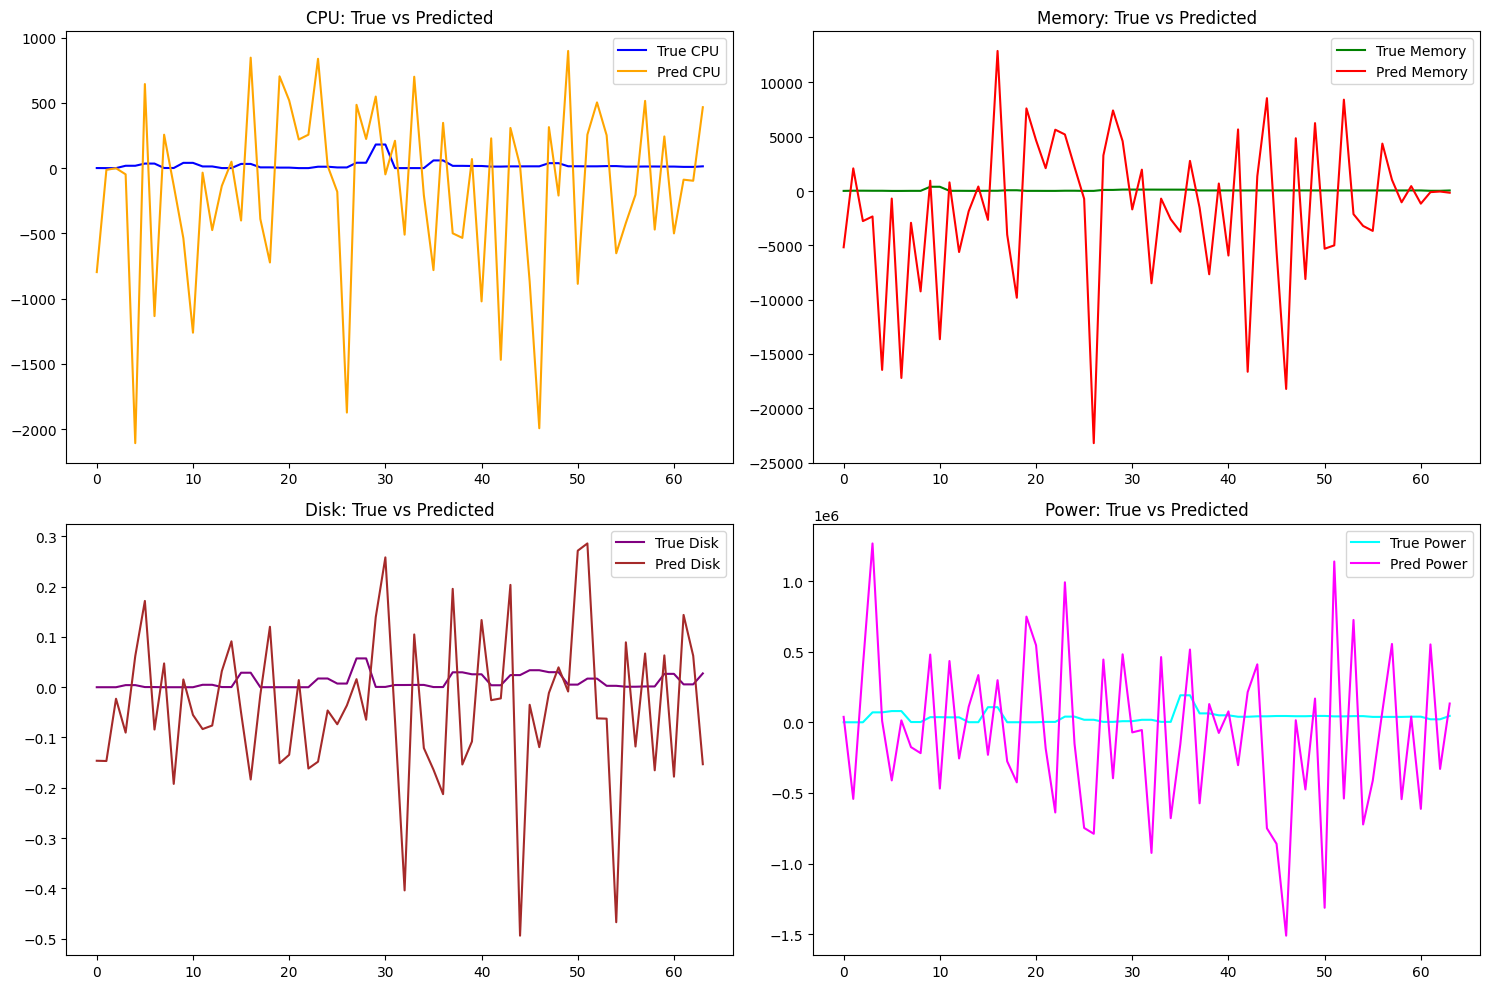

In [90]:
scaler = joblib.load("data/outputs/scaler.joblib")

model = iTransformer(
    num_variates=4, lookback_len=lookback, dim=128, depth=4, heads=8, dim_head=64, pred_length=(horizon,), num_tokens_per_variate=1, use_reversible_instance_norm=True, )
model.load_state_dict(torch.load("data/outputs/model.pth"))
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
test_df = pd.read_csv("data/outputs/test.csv")
test_ds = TimeSeriesDataset(test_df, lookback=lookback, horizon=horizon)
test_loader = DataLoader(test_ds, batch_size=32)
for x, y_true in test_loader:
    x, y_true = x.to(device), y_true.to(device)
    y_pred = model(x)
    if isinstance(y_pred, dict):
        y_pred = next(iter(y_pred.values()))
        break
# only the first batch
y_pred = y_pred.cpu().detach().numpy()
y_true = y_true.cpu().detach().numpy()
y_pred_original = scaler.inverse_transform(y_pred.reshape(-1, y_pred.shape[-1]))
y_true_original = scaler.inverse_transform(y_true.reshape(-1, y_true.shape[-1]))

# Assuming y_true and y_pred are torch tensors from the first batch or full dataset
y_pred_original = scaler.inverse_transform(y_pred.reshape(-1, y_pred.shape[-1]))
y_true_original = scaler.inverse_transform(y_true.reshape(-1, y_true.shape[-1]))

feature_names = ["CPU", "Memory", "Disk", "Power"]
plot_predictions(y_true_original, y_pred_original, feature_names)